In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
def load_dat_file(filepath):
    
    with open(filepath, 'rb') as f:
        states = []
        power_spectra = []
        eeg_var = []
        emg_var = []
        temp = []
        
        for i in range(86400):
            state = np.fromfile(f, dtype='c', count=1)[0] # 1 sleep state
            states.append(state.decode('utf-8'))
            # 401 power spectrum value
            power = np.fromfile(f, dtype=np.float32, count=401)
            power_spectra.append(power)
            misc = np.fromfile(f, dtype=np.float32, count=3) #for eeg emp and temp
            eeg_var.append(misc[0])
            emg_var.append(misc[1])
            temp.append(misc[2])
    
    return {
        'states': np.array(states),
        'power_spectra': np.array(power_spectra),
        'eeg_variance': np.array(eeg_var),
        'emg_variance': np.array(emg_var),
        'temperature': np.array(temp)
    }


each file has 96 hours of data, split into 4s epochs (86,400 total)

We extract: sleep states, frequency data, EEG/EMG variance, temperature.

Realised after that temperature seems to only be included in M2EXP*.dat files

So:

EXP1(M1EXP1 to M29EXP1) include Power Spectra and EEG/EMG variance.

EXP2 (M1EXP2 to M9EXP2) include power spectra, EEG/EMG variance and temperature.

In [3]:
Path('figures').mkdir(exist_ok=True)
Path('processed_data').mkdir(exist_ok=True)
Path('notes').mkdir(exist_ok=True)

In [4]:
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

In [5]:
def load_eeg_file(filepath):
    return np.fromfile(filepath, dtype=np.float32)

    # not using yet

In [6]:
data = load_dat_file('data/M1EXP1.dat')

In [7]:
len(data['states'])

86400

In [8]:
data['states'][:10]

array(['w', 'w', 'w', 'w', 'w', 'w', 'w', 'w', 'w', 'w'], dtype='<U1')

In [9]:
data['power_spectra'].shape

(86400, 401)

In [10]:
data['temperature'][:5]

array([0., 0., 0., 0., 0.], dtype=float32)

In [11]:
# this state map inconsistent with the one made for data conversion and what is plotted for now.

state_map = {'w': 0, 'n': 1, 'r': 2, '1': 0, '2': 1, '3': 2}
states_numeric = [state_map.get(s, -1) for s in data['states']]

In [12]:
time_hours = np.arange(len(states_numeric)) * 4 / 3600

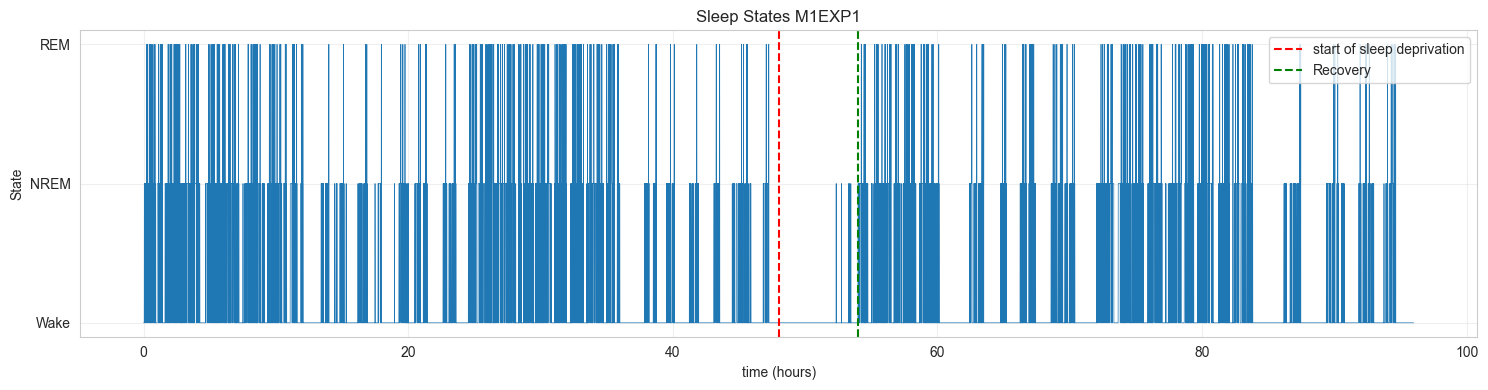

In [13]:
plt.figure(figsize=(15, 4))
plt.plot(time_hours, states_numeric, linewidth=0.5)
plt.xlabel('time (hours)')
plt.ylabel('State')
plt.yticks([0, 1, 2], ['Wake', 'NREM', 'REM'])
plt.title('Sleep States M1EXP1')

#sleep deprivation period
plt.axvline(48, color='red', linestyle='--', label='start of sleep deprivation')
plt.axvline(54, color='green', linestyle='--', label='Recovery')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

above shows the mouses sleep state (Wake/NREM/REM) over 96 hours

In [14]:
df = pd.DataFrame({
    'state': data['states'],
    'eeg_variance': data['eeg_variance'],
    'emg_variance': data['emg_variance'],
    'temperature': data['temperature']
})
# one row per 4second epoch

In [15]:
power_df = pd.DataFrame(
    data['power_spectra'],
    columns=[f'freq_{i*0.25:.2f}Hz' for i in range(401)]
)

In [16]:
df.shape, df.columns

((86400, 4),
 Index(['state', 'eeg_variance', 'emg_variance', 'temperature'], dtype='object'))

In [17]:
power_df.shape, power_df.columns
# columns are 401 frequency bins in 0.25hz steps

((86400, 401),
 Index(['freq_0.00Hz', 'freq_0.25Hz', 'freq_0.50Hz', 'freq_0.75Hz',
        'freq_1.00Hz', 'freq_1.25Hz', 'freq_1.50Hz', 'freq_1.75Hz',
        'freq_2.00Hz', 'freq_2.25Hz',
        ...
        'freq_97.75Hz', 'freq_98.00Hz', 'freq_98.25Hz', 'freq_98.50Hz',
        'freq_98.75Hz', 'freq_99.00Hz', 'freq_99.25Hz', 'freq_99.50Hz',
        'freq_99.75Hz', 'freq_100.00Hz'],
       dtype='object', length=401))

In [18]:
df.describe()

,eeg_variance,emg_variance,temperature
count,8.640000e+04,8.640000e+04,86400.0
mean,5.959103e-09,3.535736e-09,0.0
std,3.261320e-08,1.027492e-08,0.0
min,1.257427e-09,2.008353e-11,0.0
25%,3.417825e-09,9.349379e-11,0.0
50%,4.252600e-09,3.530904e-10,0.0
75%,7.620080e-09,3.389712e-09,0.0
max,6.985493e-06,4.812460e-07,0.0


In [19]:
def extract_frequency_bands_dataset(power_df):
    """
    EEG frequency bands from what i found in Hubbard & Franken (2020)   
    
    Delta band has:
    - δ1 (0.75-1.75 Hz): slow delta, linear decay, not sleep responsive
    - δ2 (2.5-3.5 Hz): fast delta,11 rapid decay, tracks sleep homeostasis

    Args:
        power_df: has 401 frequency bins (up to 100hz, in 0.25hz steps
    Returns:
        DataFrame with frequency band powers from the paper
    """
    
    freqs = np.arange(401) * 0.25
    
    bands = {
        'delta_total': (0.75, 4.0), # Total delta band
        'delta1': (0.75, 1.75), # Slow delta
        'delta2': (2.5, 3.5), # Fast delta
        
        # Other bands from the paper
        'theta': (6.0, 9.0), # Theta oscillations
        'sigma': (10.0, 15.0), # Sleep spindles
        'beta_lowgamma': (18.0, 45.0) # Higher frequencies
    }
    
    band_powers = {}
    for band_name, (low, high) in bands.items():
        idx_low = int(low / 0.25)
        idx_high = int(high / 0.25)
        # Sum power in this band
        band_powers[band_name] = power_df.iloc[:, idx_low:idx_high].sum(axis=1)
    
    return pd.DataFrame(band_powers)

Based on the paper for this exact dataset:
Hubbard et al. (2020) Nature Communications 11, 3130


**Delta band:**
  
δ1 (0.75-1.75 Hz): Slow delta, not sleep responsive

δ2 (2.5-3.5 Hz): Fast delta, tracks sleep pressure

extract_frequency_bands() takes the 401 frequency values from before and groups into the 5 bands from the paper.

these are also in the paper: 

theta (6-9 Hz) - high in REM

sigma (10-15 Hz) - sleep spindles

beta_lowgamma (18-45 Hz) - high frequency

In [20]:
band_powers = extract_frequency_bands_dataset(power_df)
df_full = pd.concat([df, band_powers], axis=1)

print(f"\nNew columns: {list(band_powers.columns)}")
print("\nBand power statistics:")
print(band_powers.describe())


New columns: ['delta_total', 'delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma']

Band power statistics:
        delta_total        delta1        delta2         theta         sigma  \
count  86400.000000  8.640000e+04  8.640000e+04  86400.000000  86400.000000   
mean       0.000243  7.020654e-05  7.541328e-05      0.000145      0.000081   
std        0.002831  1.785894e-03  3.479004e-04      0.000215      0.000202   
min        0.000010  4.378555e-07  1.989653e-07      0.000008      0.000004   
25%        0.000095  2.003522e-05  2.221928e-05      0.000079      0.000032   
50%        0.000157  3.885590e-05  4.414052e-05      0.000116      0.000051   
75%        0.000297  7.396468e-05  9.331505e-05      0.000180      0.000096   
max        0.758969  4.558672e-01  8.838184e-02      0.046278      0.040689   

       beta_lowgamma  
count   86400.000000  
mean        0.000070  
std         0.000722  
min         0.000022  
25%         0.000050  
50%         0.000059  
75%         0.0000

In [21]:
df_full['delta2_delta1_ratio'] = df_full['delta2'] / df_full['delta1']

DELTA1/ DELTA2 ratio tracks sleep pressure:

- High ratio = high sleep pressure (after waking), more sleep derived
  
- Low ratio = low sleep pressure (during sleep)

  this is the main marker form the paper

In [22]:
#ratio statistics
print(df_full['delta2_delta1_ratio'].describe())

count    86400.000000
mean         2.204394
std          3.384970
min          0.004718
25%          0.556340
50%          1.205172
75%          2.530180
max        154.469864
Name: delta2_delta1_ratio, dtype: float64


In [23]:
state_counts = df['state'].value_counts()
total_epochs = len(df)
print("Sleep State Distribution")
for state in ['w', 'n', 'r']:
    if state in state_counts.index:
        count = state_counts[state]
        hours = count * 4 / 3600
        pct = count / total_epochs * 100
        state_name = {'w': 'Wake', 'n': 'NREM', 'r': 'REM'}[state]
        print(f"{state_name:5s}: {hours:6.2f} hours ({pct:5.1f}%) - {count:,} epochs")

Sleep State Distribution
Wake :  52.67 hours ( 54.9%) - 47,407 epochs
NREM :  35.90 hours ( 37.4%) - 32,310 epochs
REM  :   4.78 hours (  5.0%) - 4,302 epochs


From some basic research the sleep states look typical for mice 
https://pubmed.ncbi.nlm.nih.gov/3838419/#:~:text=Sleep%2Dwake%20state%20was%20determined,weaker%20than%20that%20of%20activity.

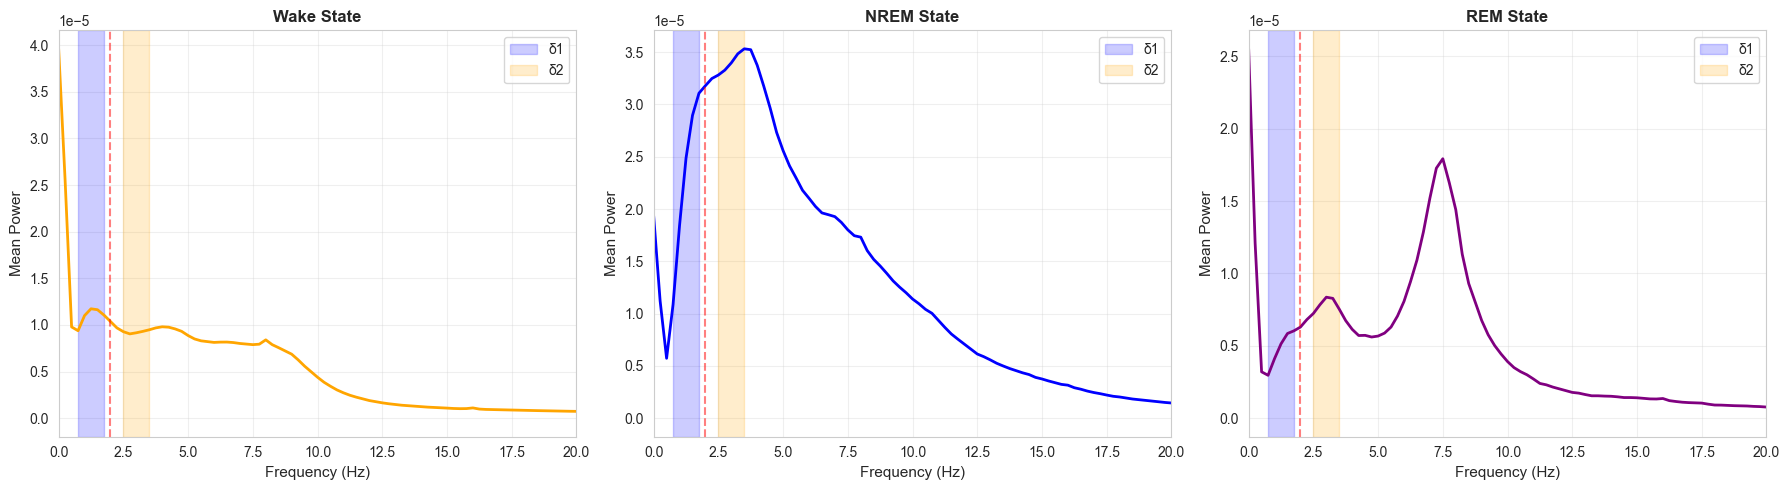

In [24]:
import seaborn as sns

# Set style
sns.set_style('whitegrid')

# mean power spectrum for each state
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
freqs = np.arange(401) * 0.25

state_colors = {'w': 'orange', 'n': 'blue', 'r': 'purple'}
state_names = {'w': 'Wake', 'n': 'NREM', 'r': 'REM'}

for idx, state in enumerate(['w', 'n', 'r']):
    state_mask = df['state'] == state
    mean_spectrum = power_df[state_mask].mean()
    
    axes[idx].plot(freqs, mean_spectrum, color=state_colors[state], linewidth=2)
    axes[idx].axvspan(0.75, 1.75, alpha=0.2, color='blue', label='δ1')
    axes[idx].axvspan(2.5, 3.5, alpha=0.2, color='orange', label='δ2')
    axes[idx].axvline(2.0, color='red', linestyle='--', alpha=0.5)
    axes[idx].set_xlabel('Frequency (Hz)', fontsize=11)
    axes[idx].set_ylabel('Mean Power', fontsize=11)
    axes[idx].set_title(f'{state_names[state]} State', fontsize=12, fontweight='bold')
    axes[idx].set_xlim(0, 20)  # Focus on 0-20 Hz
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/M1_power_spectra_by_state.png', dpi=300, bbox_inches='tight')
plt.show()

**Plot summary:**
- 3 side-by-side plots (wake, NREM, and REM)
- X-axis is frequency (0-20Hz) and Y-axis is mean power
- The blue shaded area is what lies within delta1 (0.75-1.75Hz)
- Orange shaded area is what lies within delta2 (2.5-3.5Hz)
- The red line is at 2Hz and just seperates the two types

You can see NREM has the highest power in both delta 1 and delta2

delta bands seem to seperate the sleep states well so should be good for predictive work.

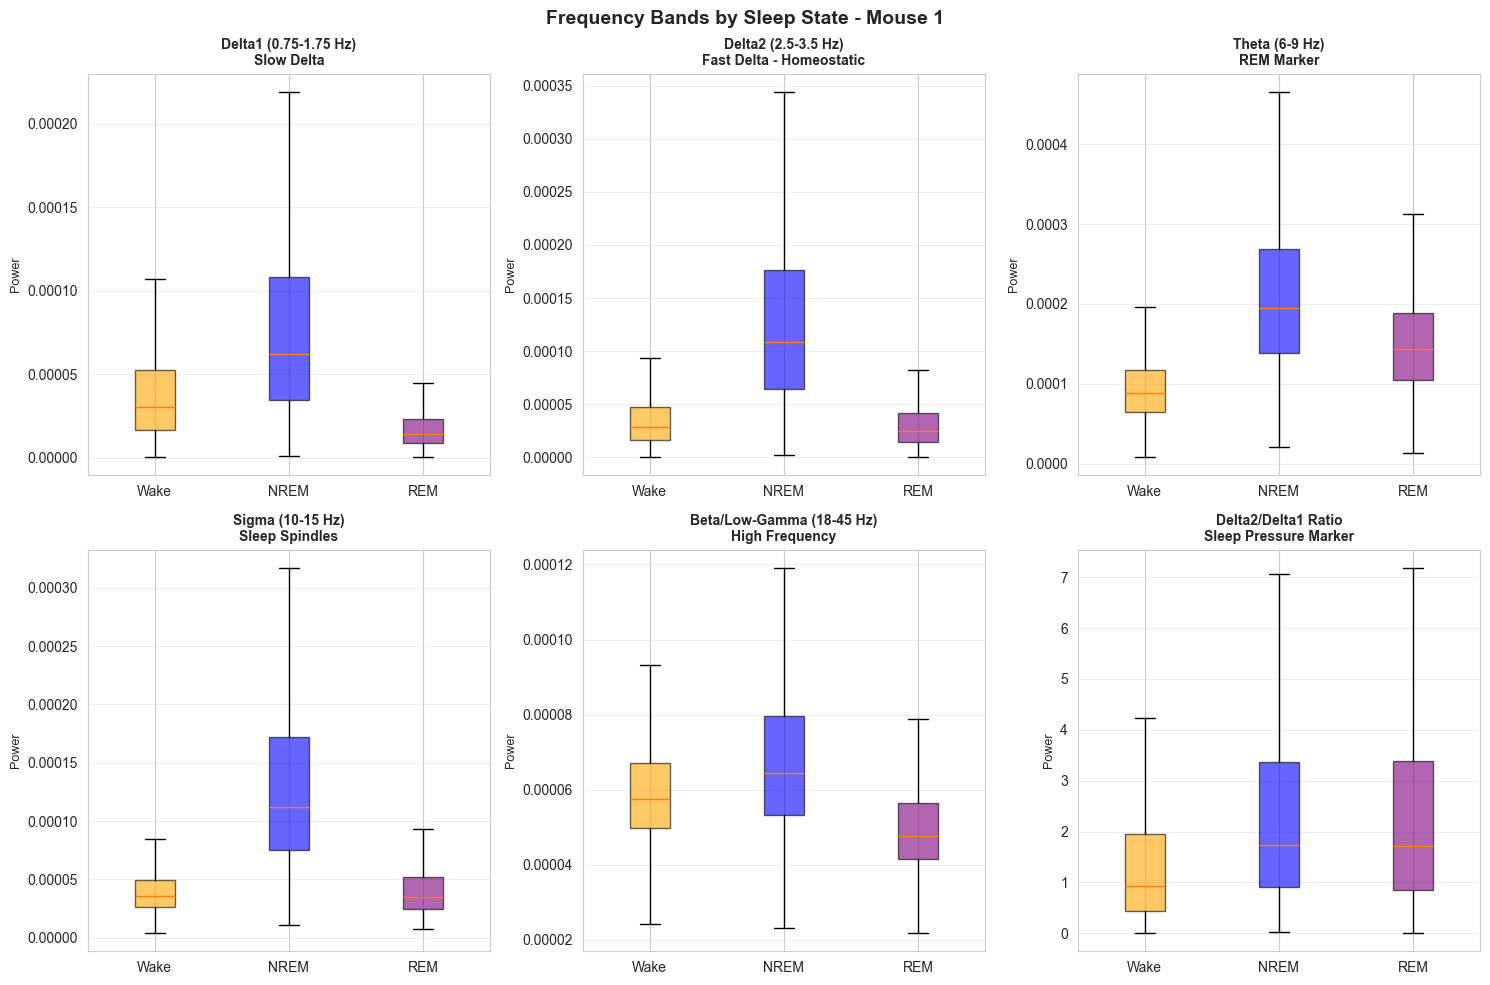

In [25]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

bands = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma', 'delta2_delta1_ratio']
titles = [
    'Delta1 (0.75-1.75 Hz)\nSlow Delta', 
    'Delta2 (2.5-3.5 Hz)\nFast Delta - Homeostatic', 
    'Theta (6-9 Hz)\nREM Marker', 
    'Sigma (10-15 Hz)\nSleep Spindles',
    'Beta/Low-Gamma (18-45 Hz)\nHigh Frequency', 
    'Delta2/Delta1 Ratio\nSleep Pressure Marker'
]

for idx, (band, title) in enumerate(zip(bands, titles)):
    data_to_plot = [df_full[df_full['state'] == state][band].values 
                    for state in ['w', 'n', 'r']]
    
    bp = axes[idx].boxplot(data_to_plot, labels=['Wake', 'NREM', 'REM'],
                           patch_artist=True, showfliers=False)
    
    colors = ['orange', 'blue', 'purple']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    axes[idx].set_title(title, fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Power', fontsize=9)
    axes[idx].grid(True, alpha=0.3, axis='y')

plt.suptitle('Frequency Bands by Sleep State - Mouse 1', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/M1_bands_by_state_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

6 plots for each frequency band and one for delta2/delta1 ratio.
Each panel has 3 boxes, Wake (Orange), NREM (Blue), REM (Purple).
The box shows middle 50% of data, within the box is the median.

Delta1 is similar across all states, doesnt seem not too useful for classification.

Delta2 is highest in NREM, very similar for wake and REM, good marker for sleep it seems.

Theta is Highest in REM, is the REM market in mice.

Sigma is highest in NREM, market for sleep spindles in mic (characteristic of NREM sleep, especially lighter stages and transitions).

Beta/low-gamma is the highest in wake.

for Delta2/Delta ratio, the more delta2 relative to delta1 is higher sleep pressure. Happens after sleep delivration and during early recovery sleep. A low ratio = low sleep pressure, during wake or after good sleep.

In [26]:
df_full.shape

(86400, 11)

In [27]:
df_full.to_csv('processed_data/M1EXP1_processed.csv', index=False)
df_full.columns

Index(['state', 'eeg_variance', 'emg_variance', 'temperature', 'delta_total',
       'delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma',
       'delta2_delta1_ratio'],
      dtype='object')

In [28]:
data_m1 = load_dat_file('data/M1EXP1.dat')
data_m2 = load_dat_file('data/M2EXP1.dat')
data_m3 = load_dat_file('data/M3EXP1.dat')
data_m4 = load_dat_file('data/M4EXP1.dat')
data_m5 = load_dat_file('data/M5EXP1.dat')
data_m6 = load_dat_file('data/M6EXP1.dat')
data_m7 = load_dat_file('data/M7EXP1.dat')
data_m8 = load_dat_file('data/M8EXP1.dat')
data_m9 = load_dat_file('data/M9EXP1.dat')
data_m10 = load_dat_file('data/M10EXP1.dat')

In [29]:
all_data = [
    ('M1EXP1', data_m1),
    ('M2EXP1', data_m2),
    ('M3EXP1', data_m3),
    ('M4EXP1', data_m4),
    ('M5EXP1', data_m5),
    ('M6EXP1', data_m6),
    ('M7EXP1', data_m7),
    ('M8EXP1', data_m8),
    ('M9EXP1', data_m9),
    ('M10EXP1', data_m10)
]

In [30]:
all_mice_dfs = []
summary_data = []

In [31]:
for mouse_id, data in all_data:    
    power_df_temp = pd.DataFrame(data['power_spectra'])
    df_temp = pd.DataFrame({
        'state': data['states'],
        'eeg_variance': data['eeg_variance'],
        'emg_variance': data['emg_variance'],
        'temperature': data['temperature']
    })
    
    # Filter to main states
    df_temp = df_temp[df_temp['state'].isin(['w', 'n', 'r'])].reset_index(drop=True)
    power_df_temp = power_df_temp.loc[df_temp.index].reset_index(drop=True)
    
    # extract frequency bands
    bands_temp = extract_frequency_bands_dataset(power_df_temp)
    df_temp = pd.concat([df_temp, bands_temp], axis=1)
    df_temp['delta2_delta1_ratio'] = df_temp['delta2'] / df_temp['delta1']
    df_temp['mouse_id'] = mouse_id
    
    all_mice_dfs.append(df_temp)
    state_counts = df_temp['state'].value_counts()
    total = len(df_temp)
    
    summary_data.append({
        'mouse_id': mouse_id,
        'total_epochs': total,
        'wake_pct': state_counts.get('w', 0) / total * 100,
        'nrem_pct': state_counts.get('n', 0) / total * 100,
        'rem_pct': state_counts.get('r', 0) / total * 100,
        'has_temperature': (data['temperature'] != 0).any(),
        'mean_delta2_delta1_ratio': df_temp['delta2_delta1_ratio'].mean()
    })

'processed' data for the 10 mice, for each mouse  create tables, filter, extract the frequency bands, calculate the delta2/delta1 ratio and add their mouse_id label

In [32]:
combined_df = pd.concat(all_mice_dfs, ignore_index=True)
summary_df = pd.DataFrame(summary_data)
#summary df has one row per mouse with summary stats

In [33]:
combined_df.shape

(843641, 12)

In [34]:
summary_df[['mouse_id', 'wake_pct', 'nrem_pct', 'rem_pct']]

,mouse_id,wake_pct,nrem_pct,rem_pct
0,M1EXP1,56.424142,38.455587,5.120270
1,M2EXP1,56.376810,38.680520,4.942670
2,M3EXP1,57.828825,37.215485,4.955690
3,M4EXP1,50.141799,44.785746,5.072455
4,M5EXP1,58.844709,36.309667,4.845624
5,M6EXP1,50.210476,44.449892,5.339632
6,M7EXP1,54.148591,41.137425,4.713984
7,M8EXP1,60.200606,35.144817,4.654577
8,M9EXP1,59.498108,36.378457,4.123435
9,M10EXP1,49.601097,44.462042,5.936861


In [35]:
print(f"Mean +/- SD:")
print(f"Wake: {summary_df['wake_pct'].mean():.1f}% +/- {summary_df['wake_pct'].std():.1f}%")
print(f"NREM: {summary_df['nrem_pct'].mean():.1f}% +/- {summary_df['nrem_pct'].std():.1f}%")
print(f"REM: {summary_df['rem_pct'].mean():.1f}% +/- {summary_df['rem_pct'].std():.1f}%")

Mean +/- SD:
Wake: 55.3% +/- 4.1%
NREM: 39.7% +/- 3.7%
REM: 5.0% +/- 0.5%


There's quite low variability so data quality seems good

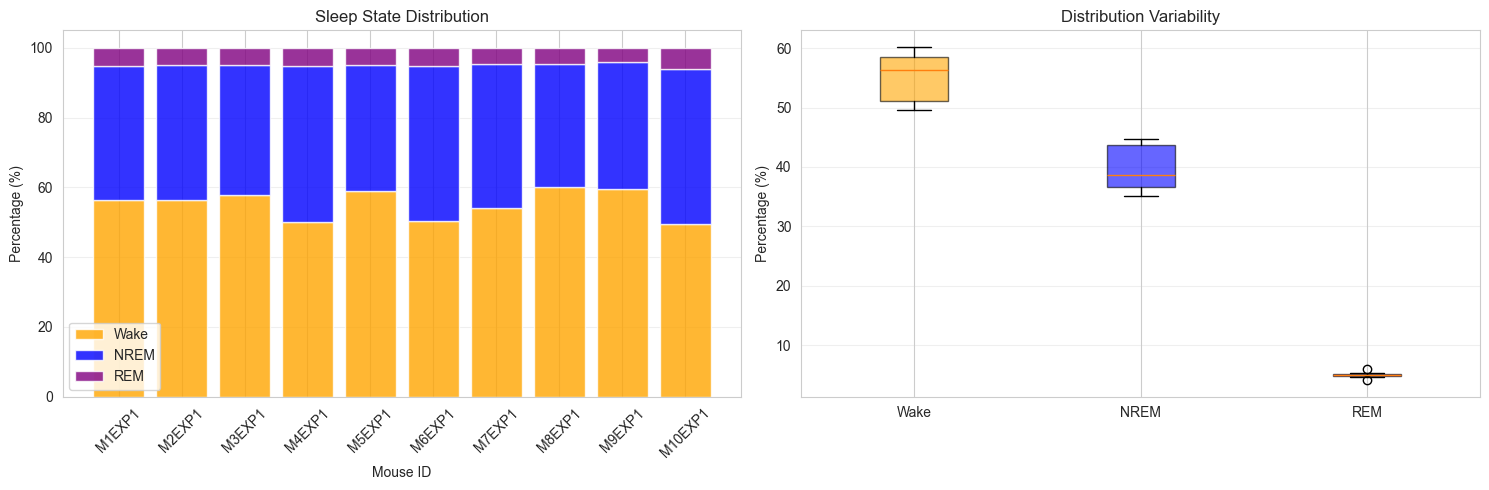

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = np.arange(len(summary_df))
axes[0].bar(x, summary_df['wake_pct'], label='Wake', color='orange', alpha=0.8)
axes[0].bar(x, summary_df['nrem_pct'], bottom=summary_df['wake_pct'], 
            label='NREM', color='blue', alpha=0.8)
axes[0].bar(x, summary_df['rem_pct'], bottom=summary_df['wake_pct'] + summary_df['nrem_pct'],
            label='REM', color='purple', alpha=0.8)
axes[0].set_xlabel('Mouse ID')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Sleep State Distribution')
axes[0].set_xticks(x)
axes[0].set_xticklabels(summary_df['mouse_id'], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Box plots
bp = axes[1].boxplot([summary_df['wake_pct'], summary_df['nrem_pct'], summary_df['rem_pct']], 
                      labels=['Wake','NREM', 'REM'], patch_artist=True)
for patch, color in zip(bp['boxes'],['orange', 'blue', 'purple']):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Distribution Variability')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Left plot of stacked bars:
- Each bar = one mouse
- colours show wake(orange), NREM(blue), REM(purple)
- all bars similar height/pattern so shows consistent sleep patterns

Right box plot:
- distribution of wake/NREM/REM percentages across all 10 mice
- tight boxes showing low variability, seems consistent

All mics have similar sleep patterns. Data quality is good, no outliers so far I can see. Should be good for classification work.

In [37]:
all_mice_names = ['M1EXP1', 'M2EXP1', 'M3EXP1', 'M4EXP1', 'M5EXP1',  'M6EXP1', 'M7EXP1', 'M8EXP1', 'M9EXP1', 'M10EXP1']

In [38]:
for i, mouse_id in enumerate(all_mice_names):
    df_mouse = all_mice_dfs[i]
    filepath = f'processed_data/{mouse_id}_processed.csv'
    df_mouse.to_csv(filepath, index=False)

combined_df.to_csv('processed_data/M1-M10_combined.csv', index=False)
summary_df.to_csv('processed_data/M1-M10_summary.csv', index=False)

## State Distribution Across All 29 EXP1 Mice

In [39]:
import glob as glob_module

# Fast reader: structured dtype reads all 86400 records in one numpy call
record_dtype = np.dtype([
    ('state', 'S1'),
    ('power', np.float32, 401),
    ('misc', np.float32, 3)
])

artifact_map = {'1': 'w', '2': 'n', '3': 'r'}

summary_rows_all = []
dat_files_all = sorted(glob_module.glob('data/M*EXP1.dat'))
print(f'Found {len(dat_files_all)} EXP1 .dat files')

for filepath in dat_files_all:
    mouse_id = os.path.splitext(os.path.basename(filepath))[0]
    records = np.fromfile(filepath, dtype=record_dtype)
    raw_states = np.array([s.decode('utf-8') for s in records['state']])
    states = np.array([artifact_map.get(s, s) for s in raw_states])
    valid = states[np.isin(states, ['w', 'n', 'r'])]
    total = len(valid)
    summary_rows_all.append({
        'mouse_id': mouse_id,
        'wake_pct': np.sum(valid == 'w') / total * 100,
        'nrem_pct': np.sum(valid == 'n') / total * 100,
        'rem_pct':  np.sum(valid == 'r') / total * 100,
    })

summary_all = pd.DataFrame(summary_rows_all)

Found 29 EXP1 .dat files


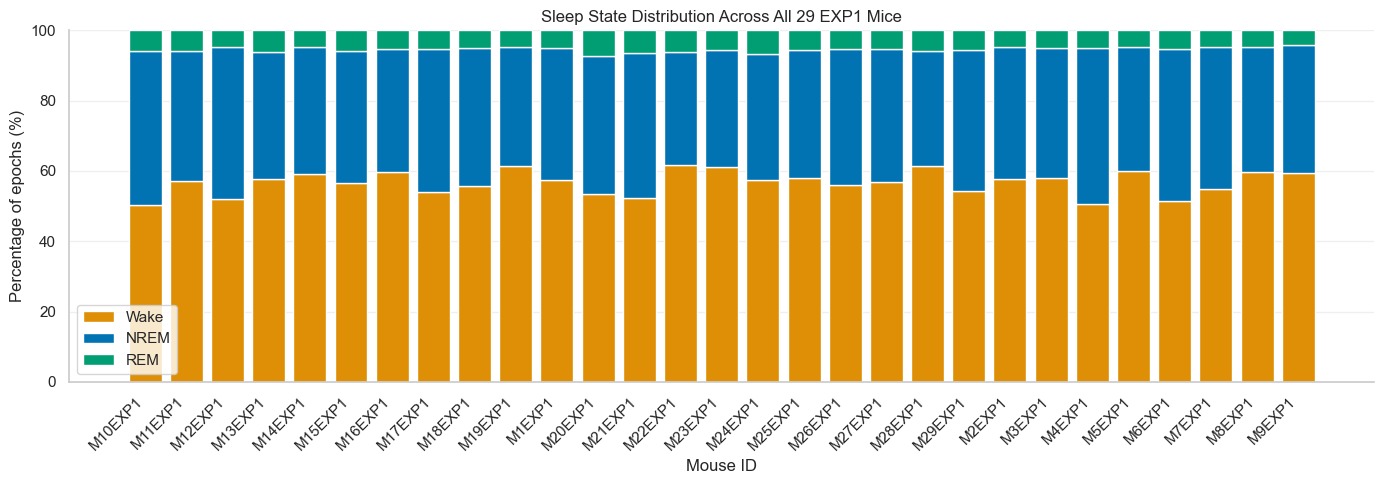

In [44]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(14, 5))

palette = sns.color_palette("colorblind")

x = np.arange(len(summary_all))
ax.bar(x, summary_all['wake_pct'], label='Wake', color=palette[1])
ax.bar(x, summary_all['nrem_pct'], bottom=summary_all['wake_pct'], label='NREM', color=palette[0])
ax.bar(x, summary_all['rem_pct'], bottom=summary_all['wake_pct'] + summary_all['nrem_pct'], label='REM', color=palette[2])

ax.set_xlabel('Mouse ID')
ax.set_ylabel('Percentage of epochs (%)')
ax.set_title('Sleep State Distribution Across All 29 EXP1 Mice')
ax.set_xticks(x)
ax.set_xticklabels(summary_all['mouse_id'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

sns.despine()

plt.tight_layout()
plt.savefig('figures/state_distribution_all.png', dpi=300, bbox_inches='tight')
plt.show()

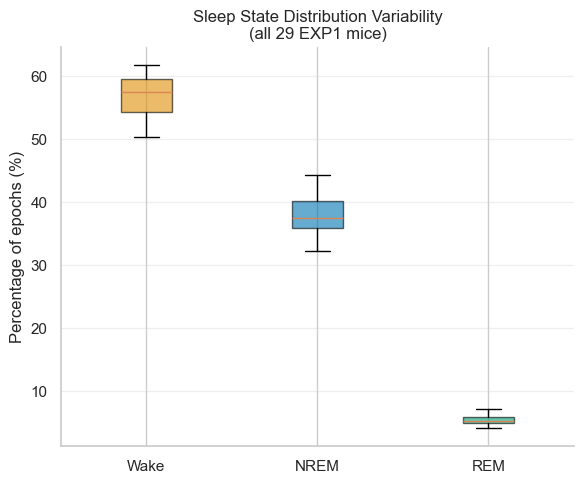

In [52]:
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'

fig, ax = plt.subplots(figsize=(6, 5))

# colorblind-friendly palette
palette = sns.color_palette("colorblind")

bp = ax.boxplot(
    [summary_all['wake_pct'], summary_all['nrem_pct'], summary_all['rem_pct']],
    labels=['Wake', 'NREM', 'REM'],
    patch_artist=True,
    showfliers=True
)

for patch, color in zip(bp['boxes'], [palette[1], palette[0], palette[2]]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel('Percentage of epochs (%)')
ax.set_title('Sleep State Distribution Variability\n(all 29 EXP1 mice)')
ax.grid(True, alpha=0.3, axis='y')

sns.despine()

plt.tight_layout()
plt.savefig('figures/state_distribution_variability.png', dpi=300, bbox_inches='tight')
plt.show()

In [46]:
# wake percentage +/- standard deviation
summary_all['wake_pct'].mean(), summary_all['wake_pct'].std()

(56.75059865900384, 3.355263097899227)

In [47]:
# nrem percentage +/- standard deviation
summary_all['nrem_pct'].mean(), summary_all['nrem_pct'].std()

(37.847102490421456, 3.305993799974249)

In [48]:
# rem percentage +/- standard deviation
summary_all['rem_pct'].mean(), summary_all['rem_pct'].std()

(5.402298850574712, 0.6796836737973873)

 EEG Power Spectra and Band Powers Across All 29 EXP1 Mice

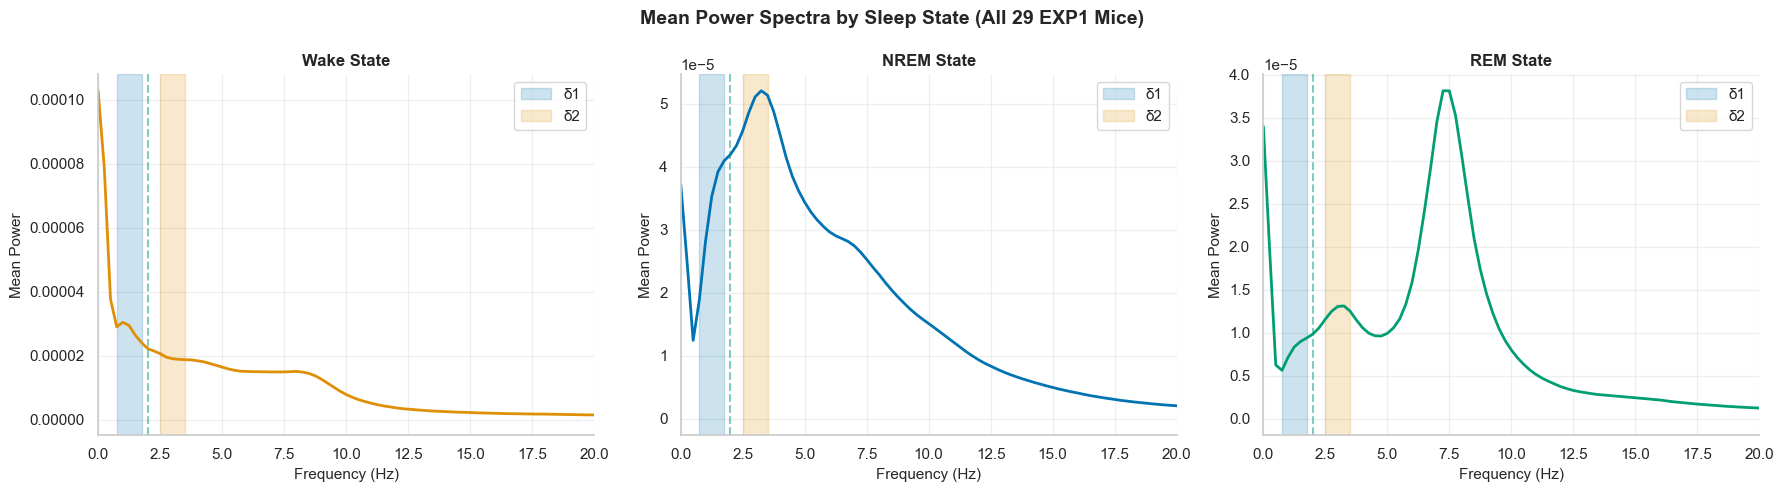

In [ ]:
record_dtype_ps = np.dtype([
    ('state', 'S1'),
    ('power', np.float32, 401),
    ('misc', np.float32, 3)
])
artifact_map_ps = {'1': 'w', '2': 'n', '3': 'r'}
dat_files_ps = sorted(glob_module.glob('data/M*EXP1.dat'))

spectra_sum  = {'w': np.zeros(401), 'n': np.zeros(401), 'r': np.zeros(401)}
spectra_count = {'w': 0, 'n': 0, 'r': 0}

for filepath in dat_files_ps:
    records = np.fromfile(filepath, dtype=record_dtype_ps)
    raw_states = np.array([s.decode('utf-8') for s in records['state']])
    states = np.array([artifact_map_ps.get(s, s) for s in raw_states])
    for st in ['w', 'n', 'r']:
        mask = states == st
        if mask.any():
            spectra_sum[st]  += records['power'][mask].sum(axis=0)
            spectra_count[st] += mask.sum()

grand_mean = {st: spectra_sum[st] / spectra_count[st] for st in ['w', 'n', 'r']}

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'

freqs = np.arange(401) * 0.25

palette = sns.color_palette("colorblind")
state_colors = {'w': palette[1], 'n': palette[0], 'r': palette[2]}
state_names  = {'w': 'Wake', 'n': 'NREM', 'r': 'REM'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, state in enumerate(['w', 'n', 'r']):
    axes[idx].plot(freqs, grand_mean[state], color=state_colors[state], linewidth=2)
    axes[idx].axvspan(0.75, 1.75, alpha=0.2, color=palette[0], label='δ1')
    axes[idx].axvspan(2.5,  3.5,  alpha=0.2, color=palette[1], label='δ2')
    axes[idx].axvline(2.0, color=palette[2], linestyle='--', alpha=0.5)

    axes[idx].set_xlabel('Frequency (Hz)', fontsize=11)
    axes[idx].set_ylabel('Mean Power', fontsize=11)
    axes[idx].set_title(f'{state_names[state]} State', fontsize=12, fontweight='bold')
    axes[idx].set_xlim(0, 20)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

    sns.despine(ax=axes[idx])

plt.suptitle('Mean Power Spectra by Sleep State (All 29 EXP1 Mice)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [50]:
band_defs = {
    'delta1': (0.75, 1.75),
    'delta2': (2.5, 3.5),
    'theta': (6.0, 9.0),
    'sigma': (10.0, 15.0),
    'beta_lowgamma': (18.0, 45.0)
}
band_pools = {st: {b: [] for b in list(band_defs) + ['delta2_delta1_ratio']} for st in ['w', 'n', 'r']}

record_dtype_bp = np.dtype([
    ('state', 'S1'),
    ('power', np.float32, 401),
    ('misc',  np.float32, 3)
])

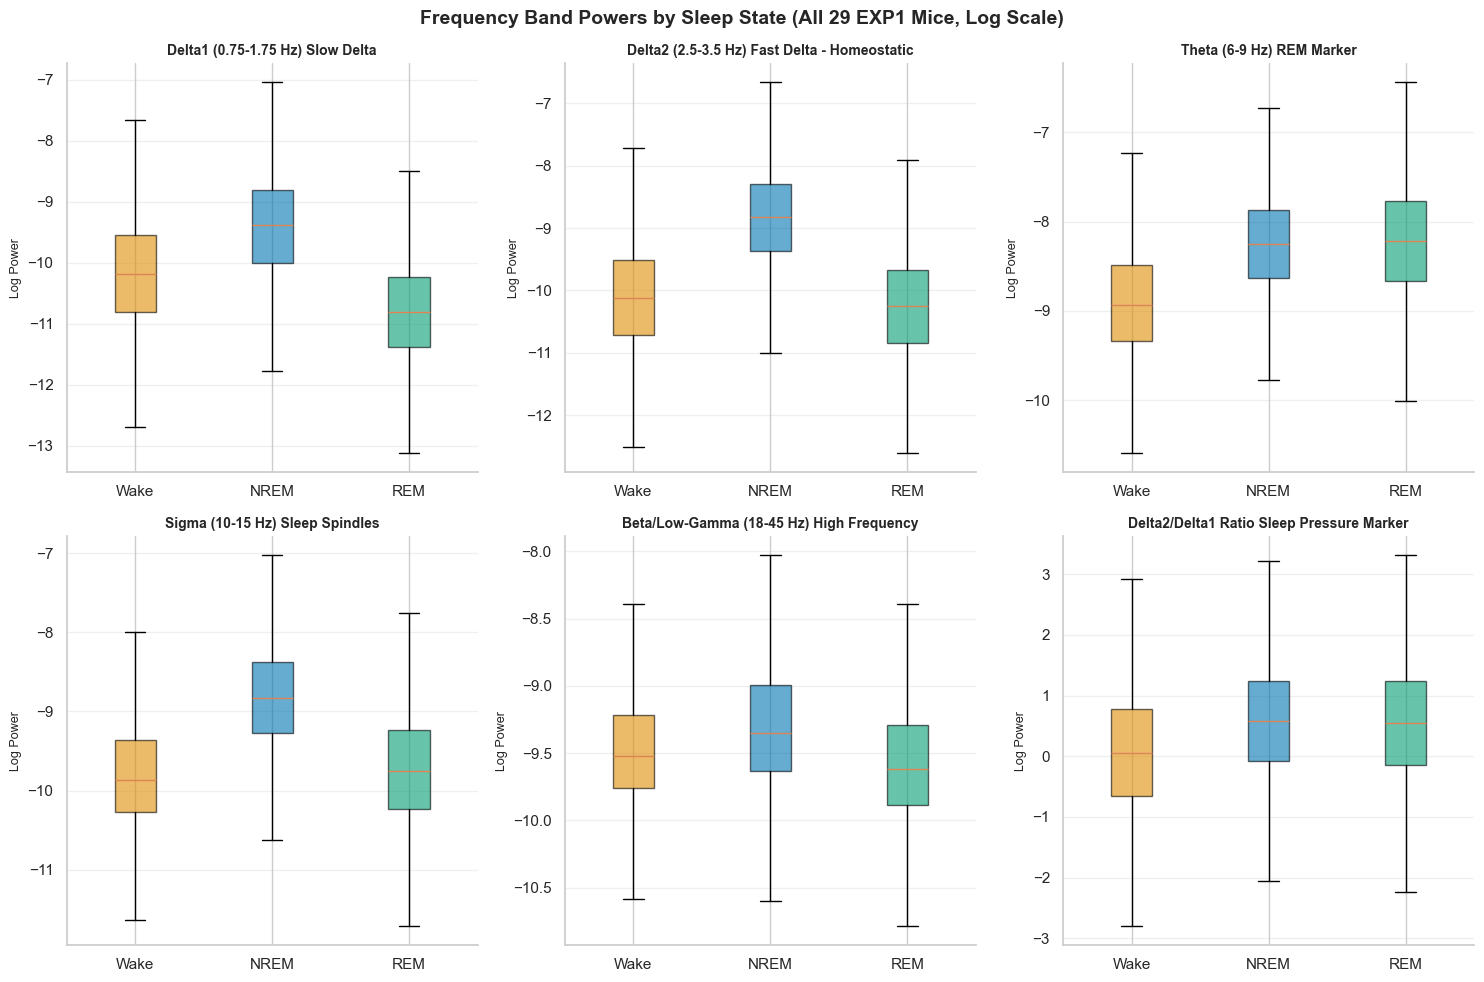

In [ ]:
band_pools = {st: {b: [] for b in list(band_defs) + ['delta2_delta1_ratio']} for st in ['w', 'n', 'r']}

for filepath in sorted(glob_module.glob('data/M*EXP1.dat')):
    records    = np.fromfile(filepath, dtype=record_dtype_bp)
    raw_states = np.array([s.decode('utf-8') for s in records['state']])
    states_arr = np.array([artifact_map_ps.get(s, s) for s in raw_states])

    for st in ['w', 'n', 'r']:
        mask = states_arr == st
        if not mask.any():
            continue

        ps = records['power'][mask].astype(np.float64)

        band_vals = {}
        for band_name, (low, high) in band_defs.items():
            idx_low = int(low / 0.25)
            idx_high = int(high/0.25)
            band_power = ps[:, idx_low:idx_high].sum(axis=1).clip(min=1e-30)
            band_vals[band_name] = np.log(band_power)

        band_vals['delta2_delta1_ratio'] = band_vals['delta2'] - band_vals['delta1']

        for band_name in band_pools[st]:
            band_pools[st][band_name].append(band_vals[band_name])

for st in ['w', 'n', 'r']:
    for band_name in band_pools[st]:
        band_pools[st][band_name] = np.concatenate(band_pools[st][band_name])

bands_to_plot = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma', 'delta2_delta1_ratio']
panel_titles  = ['Delta1 (0.75-1.75 Hz) Slow Delta', 'Delta2 (2.5-3.5 Hz) Fast Delta - Homeostatic', 'Theta (6-9 Hz) REM Marker',
    'Sigma (10-15 Hz) Sleep Spindles', 'Beta/Low-Gamma (18-45 Hz) High Frequency', 'Delta2/Delta1 Ratio Sleep Pressure Marker']

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'

palette = sns.color_palette("colorblind")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, band_name, title in zip(axes, bands_to_plot, panel_titles):
    data_by_state = [band_pools[st][band_name] for st in ['w', 'n', 'r']]

    bp = ax.boxplot(
        data_by_state,
        labels=['Wake', 'NREM', 'REM'],
        patch_artist=True,
        showfliers=False
    )

    for patch, color in zip(bp['boxes'], [palette[1], palette[0], palette[2]]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_ylabel('Log Power', fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    sns.despine(ax=ax)

plt.suptitle('Frequency Band Powers by Sleep State (All 29 EXP1 Mice, Log Scale)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

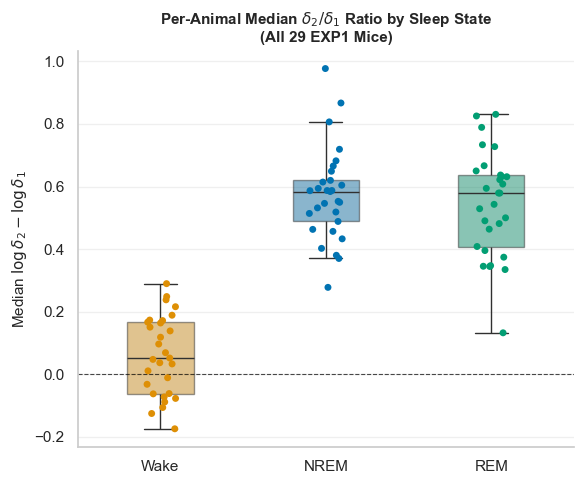

In [ ]:
per_animal_rows = []

for filepath in sorted(glob_module.glob('data/M*EXP1.dat')):
    mouse_id = os.path.splitext(os.path.basename(filepath))[0]
    records = np.fromfile(filepath, dtype=record_dtype_bp)
    raw_states = np.array([s.decode('utf-8') for s in records['state']])
    states_arr = np.array([artifact_map_ps.get(s, s) for s in raw_states])
    ps = records['power'].astype(np.float64)

    idx_low1 = int(band_defs['delta1'][0] / 0.25)
    idx_high1 = int(band_defs['delta1'][1] / 0.25)
    idx_low2 = int(band_defs['delta2'][0] / 0.25)
    idx_high2 = int(band_defs['delta2'][1] / 0.25)

    log_d1 = np.log(ps[:, idx_low1:idx_high1].sum(axis=1).clip(min=1e-30))
    log_d2 = np.log(ps[:, idx_low2:idx_high2].sum(axis=1).clip(min=1e-30))
    ratio = log_d2 - log_d1

    for st in ['w', 'n', 'r']:
        mask = states_arr == st
        if mask.any():
            per_animal_rows.append({'mouse_id': mouse_id, 'state': st, 'median_ratio': np.median(ratio[mask])})

per_animal_df = pd.DataFrame(per_animal_rows)

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'Arial'
palette = sns.color_palette('colorblind')
state_order = ['w', 'n', 'r']
state_labels = ['Wake', 'NREM', 'REM']
state_palette = {'w': palette[1], 'n': palette[0], 'r': palette[2]}

fig, ax = plt.subplots(figsize=(6, 5))

sns.boxplot(data=per_animal_df, x='state', y='median_ratio', order=state_order, palette=state_palette, width=0.4, showfliers=False,
            boxprops=dict(alpha=0.5), ax=ax)
sns.stripplot(data=per_animal_df, x='state', y='median_ratio', order=state_order, palette=state_palette, size=5, jitter=True, ax=ax)

ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)
ax.set_xticklabels(state_labels)
ax.set_xlabel('')
ax.set_ylabel('Median $\\log\\delta_2 - \\log\\delta_1$', fontsize=11)
ax.set_title('Per-Animal Median $\\delta_2/\\delta_1$ Ratio by Sleep State\n(All 29 EXP1 Mice)', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
sns.despine()

plt.tight_layout()
plt.savefig('figures/delta2_delta1_ratio_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
